# Exploratory Data Analysis (EDA) — Kyivan Dataset

Этот ноутбук предназначен для анализа финального собранного датасета исторических славянских текстов.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from collections import Counter

# Настройки графиков
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Загрузка данных
Читаем `final_dataset.jsonl` в `pandas.DataFrame`.


In [10]:
data = []
with open('../data/final_dataset.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
df['text_len_chars'] = df['text'].apply(len)
df['text_len_words'] = df['text'].apply(lambda x: len(x.split()))

print(f"Всего документов: {len(df)}")
display(df.head())


Всего документов: 5181


,doc_id,text,macro_dialect,date_interval,date_target,date_number,category,original_dialect,original,target,masked,number,date,category_mapped,region,genre,text_len_chars,text_len_words
0,gramoty_akty_14_16/28_akty_XIV_XVI,"Се яз, Миня, чернец игуменов Никонов, Сергиева...",OES,"[1300, 1700]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,unknown,Middle Russian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,187,32
1,NaN,и позвале насъ · господине на комелъ и пошли є...,NW,"[1280, 1300]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,письма,NaN,и позвале насъ · господине на комелъ и пошли є...,и позвале насъ · господине на комелъ и пошли є...,и позвале насъ · господине на комелъ и пошли є...,929,1280‒1300 (с вероятным смещением вперёд),letters,Новгород,частное письмо,110,20
2,NaN,[GAP] го слово площ[GAP] ги аще на не азо ги н...,NW,"[1240, 1260]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.476...",NaN,церковные тексты,NaN,[GAP] го слово пло[щ][GAP] г[и] аще на не азо ...,[GAP] го слово площ[GAP] ги аще на не азо ги н...,[GAP] го слово пло[GAP] г[GAP] аще на не азо г...,331,1240‒1260 (с вероятным смещением вперёд),religious,Новгород,литургический текст,57,13
3,nkrya_scraped_343,Гсдрь мои млстивои Степанъ Григорьевичь здравъ...,OES,"[1651, 1700]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,DAILY,starorus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204,33
4,nkrya_scraped_1516,"Список · Се аз , князь великий Василей Василье...",OES,"[1400, 1500]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,LEGAL,starorus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,237,38


## 2. Распределение Макро-Диалектов
Посмотрим, как сбалансированы наши 4 класса: `OES` (древнерусский), `CS` (церковнославянский), `NW` (новгородский) и `SW` (западнорусский).


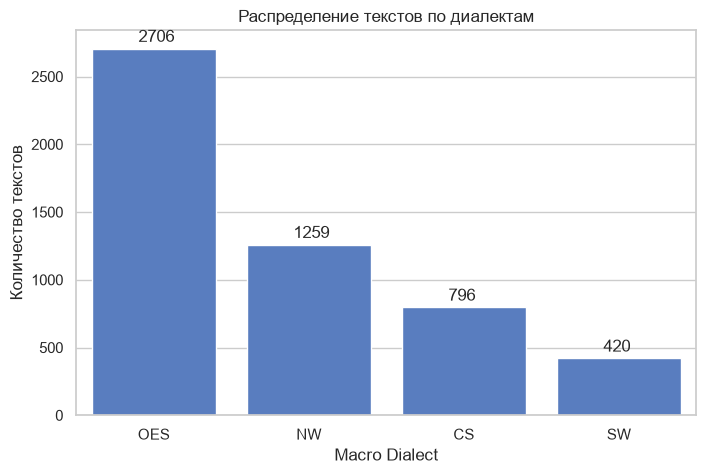

In [11]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='macro_dialect', order=df['macro_dialect'].value_counts().index)
plt.title('Распределение текстов по диалектам')
plt.xlabel('Macro Dialect')
plt.ylabel('Количество текстов')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50))
plt.show()


## 3. Распределение по времени (Вектора дат)
У нас есть 20-мерные вектора `date_target`, представляющие корзины по 50 лет от 800 до 1800 года.
Суммируем все вектора, чтобы получить общее распределение текстов во времени.


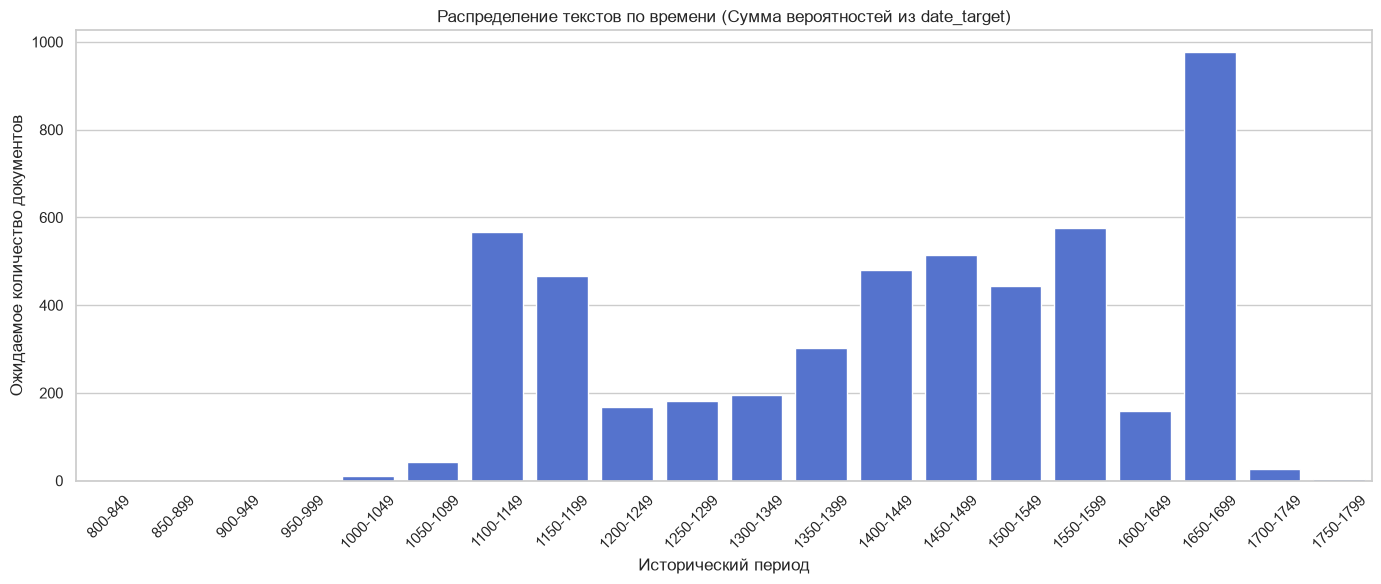

In [12]:
# Извлекаем все вектора и суммируем их (каждый вектор - это вероятность)
all_targets = np.array(df['date_target'].tolist())
sum_targets = all_targets.sum(axis=0)

# Подготовим подписи для корзин
start_year = 800
bucket_size = 50
labels = [f"{start_year + i*bucket_size}-{start_year + (i+1)*bucket_size - 1}" for i in range(20)]

plt.figure(figsize=(14, 6))
sns.barplot(x=labels, y=sum_targets, color='royalblue')
plt.xticks(rotation=45)
plt.title('Распределение текстов по времени (Сумма вероятностей из date_target)')
plt.xlabel('Исторический период')
plt.ylabel('Ожидаемое количество документов')
plt.tight_layout()
plt.show()


## 4. Длина текстов
Проанализируем среднюю длину текста в зависимости от диалекта/источника.


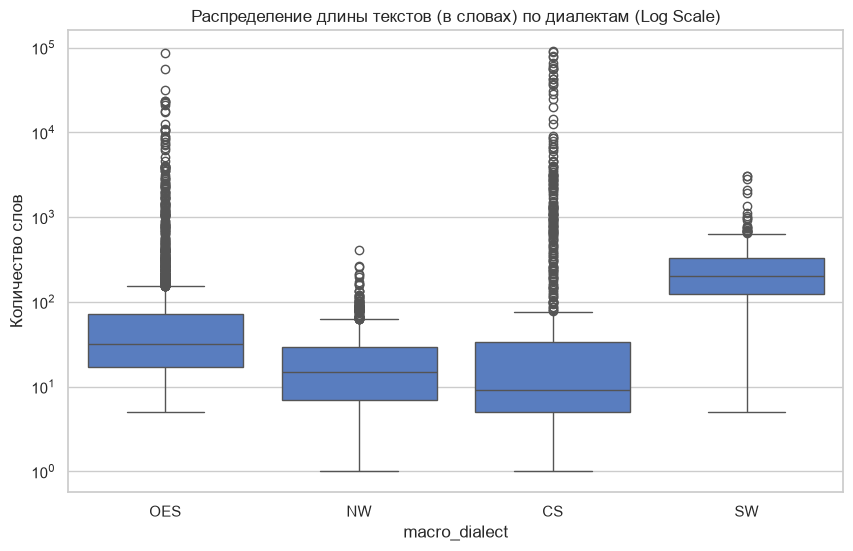

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='macro_dialect', y='text_len_words')
plt.yscale('log')
plt.title('Распределение длины текстов (в словах) по диалектам (Log Scale)')
plt.ylabel('Количество слов')
plt.show()


## 5. Анализ символов (Специфика исторической орфографии)
Посмотрим на самые частые и самые редкие символы в нашем корпусе, чтобы убедиться, что мы сохранили «юсы» и «омеги».


In [15]:
all_text = " ".join(df['text'].tolist())
char_counts = Counter(all_text)

# Исключаем пробелы и стандартные знаки препинания для наглядности
import string
exclude = set(string.ascii_letters + string.punctuation + string.digits + " ")
filtered_chars = {k: v for k, v in char_counts.items() if k not in exclude}

top_chars = dict(Counter(filtered_chars).most_common(20))
bottom_chars = dict(Counter(filtered_chars).most_common()[-30:])

print("--- ТОП 20 кириллических символов ---")
print(top_chars)

print("\n--- Редкие символы (Юсы, Омеги, диакритика) ---")
print(bottom_chars)


--- ТОП 20 кириллических символов ---
{'о': 846835, 'и': 823086, 'а': 668397, 'е': 635261, 'с': 501974, 'т': 491037, 'н': 470864, 'в': 437010, 'р': 392092, 'м': 323186, 'л': 320803, 'ъ': 303678, 'д': 303365, 'к': 247695, 'п': 234068, 'ь': 210979, 'ѣ': 176510, 'г': 173742, 'б': 172808, 'у': 172164}

--- Редкие символы (Юсы, Омеги, диакритика) ---
{'ł': 1, 'ú': 1, 'Ꙉ': 1, '⁓': 1, 'Ꙃ': 1, 'ω': 1, '⁙': 1, 'ґ': 1, 'Ἀ': 1, 'χ': 1, 'ί': 1, 'Π': 1, 'ό': 1, 'ζ': 1, 'υ': 1, 'Θ': 1, 'δ': 1, 'ώ': 1, '∷': 1, 'ᴤ': 1, 'Ѷ': 1, 'Ѓ': 1, 'Ќ': 1, 'Ꙭ': 1, '̴': 1, 'Ï': 1, '\u200e': 1, 'μ': 1, 'ó': 1, 'Í': 1}
